In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import random
import numpy as np
import time
from typing import Tuple, List, Optional
import os
import matplotlib.pyplot as plt
seed = 42

In [2]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

In [ ]:

base_requests = [1, 2, 3, 4, 5, 1, 2, 3, 4, 5]


distance = [
    [7770, 6896, 9292,  661, 5776, 7770, 6896, 9292,  661, 5776],
    [1360, 9166, 8933, 4797, 2562, 1360, 9166, 8933, 4797, 2562],
    [5890, 9774, 8013, 1495,  564, 5890, 9774, 8013, 1495,  564],
    [5691, 3058, 3112, 8129, 8506, 5691, 3058, 3112, 8129, 8506],
    [6234, 8349, 7541, 9967, 3068, 6234, 8349, 7541, 9967, 3068],
    [6765, 2547, 6735, 1516, 5963, 6765, 2547, 6735, 1516, 5963],
    [ 966, 3247, 5986, 8369, 2527,  966, 3247, 5986, 8369, 2527],
    [4926, 9667, 7599, 6939, 3195, 4926, 9667, 7599, 6939, 3195],
    [6078,  689, 1275, 8392, 5758, 6078,  689, 1275, 8392, 5758],
    [8822, 3234, 8726, 7363, 6118, 8822, 3234, 8726, 7363, 6118],
    [2185, 3505, 3652, 8416, 7236, 2185, 3505, 3652, 8416, 7236],
    [1269, 5158, 2085, 9029,  891, 1269, 5158, 2085, 9029,  891],
    [7449, 2399, 4443, 1378, 6392, 7449, 2399, 4443, 1378, 6392],
    [2933, 8234, 8055, 9768, 4061, 2933, 8234, 8055, 9768, 4061],
    [5811, 1767, 3573, 5387, 6684, 5811, 1767, 3573, 5387, 6684],
    [5551, 2028, 1521, 5359, 3599, 5551, 2028, 1521, 5359, 3599],
    [7561, 3732,  528, 7075,  528, 7561, 3732,  528, 7075,  528],
    [7574, 5977, 8907,  858, 3393, 7574, 5977, 8907,  858, 3393],
    [9117,  102, 2261, 9443,  122, 9117,  102, 2261, 9443,  122],
    [ 801, 8643, 4722,  398, 5485,  801, 8643, 4722,  398, 5485],
]

duration = [
    [537, 199, 471, 838, 395, 537, 199, 471, 838, 395],
    [ 64, 269,  84,  91, 936,  64, 269,  84,  91, 936],
    [741, 807, 588, 796,  71, 741, 807, 588, 796,  71],
    [269,  68, 102, 985, 462, 269,  68, 102, 985, 462],
    [497, 395,  12, 404, 543, 497, 395,  12, 404, 543],
    [995, 385,  38, 996, 660, 995, 385,  38, 996, 660],
    [184, 803,  47, 134, 701, 184, 803,  47, 134, 701],
    [164, 317, 589, 816, 587, 164, 317, 589, 816, 587],
    [649, 636, 151, 395, 893, 649, 636, 151, 395, 893],
    [846,  29, 661, 100, 612, 846,  29, 661, 100, 612],
    [174, 913, 648, 882,  42, 174, 913, 648, 882,  42],
    [142, 404, 108, 625, 768, 142, 404, 108, 625, 768],
    [314, 181, 205, 757, 747, 314, 181, 205, 757, 747],
    [ 76, 703, 716, 898, 333,  76, 703, 716, 898, 333],
    [461, 587,  80,  33, 999, 461, 587,  80,  33, 999],
    [607, 127, 620,  47, 274, 607, 127, 620,  47, 274],
    [677, 205, 311,  81, 731, 677, 205, 311,  81, 731],
    [484, 991,  14, 187, 107, 484, 991,  14, 187, 107],
    [278, 733, 734, 762, 458, 278, 733, 734, 762, 458],
    [269,  85,  50, 893, 180, 269,  85,  50, 893, 180],
]

cum_order = [
    [3.75, 9.34, 6.22, 6.11, 1.01, 3.75, 9.34, 6.22, 6.11, 1.01],
    [9.54, 3.32, 4.06, 4.64, 3.19, 9.54, 3.32, 4.06, 4.64, 3.19],
    [0.36, 3.27, 2.68, 0.34, 0.50, 0.36, 3.27, 2.68, 0.34, 0.50],
    [4.14, 1.80, 2.70, 2.58, 3.42, 4.14, 1.80, 2.70, 2.58, 3.42],
    [3.24, 9.33, 2.17, 4.54, 7.87, 3.24, 9.33, 2.17, 4.54, 7.87],
    [1.39, 2.30, 8.43, 6.29, 1.13, 1.39, 2.30, 8.43, 6.29, 1.13],
    [4.34, 7.15, 3.79, 0.87, 5.05, 4.34, 7.15, 3.79, 0.87, 5.05],
    [9.41, 6.65, 4.07, 8.14, 5.86, 9.41, 6.65, 4.07, 8.14, 5.86],
    [2.46, 3.53, 2.90, 2.97, 4.48, 2.46, 3.53, 2.90, 2.97, 4.48],
    [8.97, 0.24, 9.37, 2.60, 8.02, 8.97, 0.24, 9.37, 2.60, 8.02],
    [1.18, 1.44, 9.76, 6.12, 3.23, 1.18, 1.44, 9.76, 6.12, 3.23],
    [1.42, 1.41, 9.32, 0.54, 2.47, 1.42, 1.41, 9.32, 0.54, 2.47],
    [0.27, 4.19, 0.68, 5.70, 6.18, 0.27, 4.19, 0.68, 5.70, 6.18],
    [4.90, 0.24, 1.13, 4.77, 7.14, 4.90, 0.24, 1.13, 4.77, 7.14],
    [6.26, 6.64, 2.57, 0.19, 4.24, 6.26, 6.64, 2.57, 0.19, 4.24],
    [1.71, 0.54, 6.12, 3.04, 4.12, 1.71, 0.54, 6.12, 3.04, 4.12],
    [7.07, 5.06, 3.26, 0.07, 0.08, 7.07, 5.06, 3.26, 0.07, 0.08],
    [7.60, 9.63, 9.11, 0.26, 8.72, 7.60, 9.63, 9.11, 0.26, 8.72],
    [4.67, 4.10, 9.04, 1.36, 4.38, 4.67, 4.10, 9.04, 1.36, 4.38],
    [1.46, 5.12, 5.58, 2.68, 6.25, 1.46, 5.12, 5.58, 2.68, 6.25],
]

base_order_rate = [26.0, 46.0, 10.0, 19.0, 47.0, 26.0, 46.0, 10.0, 17.0, 47.0]

taxis_battery = [100 for i in range(20)]

battery_threshold = 10



flat_duration = [item for row in duration for item in row]
min_duration = min(flat_duration)
max_duration = max(flat_duration)

flat_cumulative_order_rate = [item for row in cum_order for item in row]
min_cumulative_order_rate = min(flat_cumulative_order_rate)
max_cumulative_order_rate = max(flat_cumulative_order_rate)


min_base_order_rate = min(base_order_rate)
max_base_order_rate = max(base_order_rate)


alpha = 1
beta = 1
gamma = 1

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
def create_profit_matrix_from_environment(base_order_rate: torch.Tensor, cumulative_order_rate: torch.Tensor, duration_matrix: torch.Tensor, weight_matrix: torch.Tensor, lambda2: float = 15.0, miu: float = 0.1, capacity: float = 20.0) -> torch.Tensor:
    n_requests, n_taxis = cumulative_order_rate.shape
    profit_matrix = torch.zeros_like(cumulative_order_rate)

    
    for i in range(n_requests):
        for j in range(n_taxis):
            order_rate = base_order_rate[i]
            cum_order = cumulative_order_rate[i, j]
            duration = duration_matrix[i, j]
            battery_level = weight_matrix[i, j]
            d_hat = max((duration - min_duration), duration) / max((max_duration - min_duration), duration)
            cumulative_hat = 0 if(cum_order == 0) else max((cum_order - min_cumulative_order_rate), cum_order) / max((max_cumulative_order_rate - min_cumulative_order_rate), cum_order)
            base_order_rate_hat = max((order_rate - min_base_order_rate), order_rate) / max((max_base_order_rate - min_base_order_rate), order_rate)                                                                                
            fir = (alpha * (1- d_hat)) + (beta * (1 - cumulative_hat)) + (gamma * base_order_rate_hat)

            expected_revenue = fir
            battery_penalty = lambda2 * F.relu(capacity - battery_level)
            profit_matrix[i, j] = expected_revenue - battery_penalty
            
    return profit_matrix



In [ ]:
def create_weight_matrix_from_environment(distance_matrix: torch.Tensor, duration_matrix: torch.Tensor, initial_battery: float = 100.0, alpha_d: float = 0.00024524, alpha_t: float = 0.0) -> torch.Tensor:
    battery_consumption = alpha_d * distance_matrix + alpha_t * duration_matrix
    weight_matrix = initial_battery - battery_consumption
    return weight_matrix


In [ ]:
def convert_assignment_to_prec_format(assignment_matrix: torch.Tensor) -> List[Optional[int]]:
    num_requests, num_taxis = assignment_matrix.shape
    prec_assignment = [None] * num_taxis

    for req in range(num_requests):
        assigned_taxis = (assignment_matrix[req] > 0.5).nonzero(as_tuple=True)[0]
        if len(assigned_taxis) > 0:
            taxi_idx = assigned_taxis[0].item()
            prec_assignment[taxi_idx] = req

    return prec_assignment


In [ ]:
def generate_hard_assignment(logits_matrix: torch.Tensor, weight_matrix: torch.Tensor, capacity: float = 20.0) -> torch.Tensor:
    num_requests, num_taxis = logits_matrix.shape
    assignment = torch.zeros_like(logits_matrix)

    valid_mask = (weight_matrix >= capacity).float()
    masked_logits = logits_matrix * valid_mask + (1 - valid_mask) * (-1e9)

    used_taxis = torch.zeros(num_taxis, dtype=torch.bool, device=logits_matrix.device)

    for req in range(num_requests):
        available_logits = masked_logits[req].clone()
        available_logits[used_taxis] = -1e9

        if available_logits.max() > -1e8:
            best_taxi = available_logits.argmax()
            assignment[req, best_taxi] = 1.0
            used_taxis[best_taxi] = True

    return assignment


In [ ]:
class ChannelAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.linear = nn.Linear(dim * 3, dim)
        self.dropout = nn.Dropout(0.1)

    def forward(self, features):
        if features.numel() == 0:
            return torch.ones(features.size(-1), device=features.device)

        stats = torch.cat([
            features.max(dim=0)[0],
            features.min(dim=0)[0],
            features.mean(dim=0)
        ], dim=0)
        attention = torch.sigmoid(self.dropout(self.linear(stats)))
        return attention

class EdgeEncoder(nn.Module):
    def __init__(self, out_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(1, out_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(out_dim, out_dim),
            nn.LayerNorm(out_dim)
        )

    def forward(self, edge_weights):
        
        edge_weights = edge_weights.view(-1, 1)
        
        normalized_weights = torch.tanh(edge_weights / 100.0)
        if self.training:
            torch.manual_seed(seed)
            noise = torch.randn_like(normalized_weights) * 0.01
            normalized_weights = normalized_weights + noise
        return self.mlp(normalized_weights)

class EdgeUpdate(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.edge_mlp = nn.Sequential(
            nn.Linear(dim * 3, dim * 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(dim * 2, dim),
            nn.LayerNorm(dim)
        )

    def forward(self, edge_feats, node_feats, edge_idx, c_v, c_e):
        src = node_feats[edge_idx[:, 0]] * c_v.unsqueeze(0)
        tgt = node_feats[edge_idx[:, 1]] * c_v.unsqueeze(0)
        edge = edge_feats * c_e.unsqueeze(0)
        combined = torch.cat([src, tgt, edge], dim=1)
        return self.edge_mlp(combined)

class NodeUpdate(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.rho_v1 = nn.Sequential(
            nn.Linear(dim * 2, dim * 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(dim * 2, dim),
            nn.LayerNorm(dim)
        )
        self.tau = nn.Sequential(
            nn.Linear(dim * 2, dim),
            nn.ReLU(),
            nn.Linear(dim, 1),
            nn.Sigmoid()
        )
        self.rho_v2 = nn.Sequential(
            nn.Linear(dim * 2, dim * 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(dim * 2, dim),
            nn.LayerNorm(dim)
        )

    def forward(self, edge_feats, edge_idx, node_feats, c_e, c_v):
        num_nodes = node_feats.size(0)
        dim = self.dim
        agg_feats = torch.zeros((num_nodes, dim), device=node_feats.device)
        count = torch.zeros(num_nodes, device=node_feats.device)

        for k in range(edge_feats.size(0)):
            i, j = edge_idx[k]
            e_ij = edge_feats[k] * c_e
            v_j = node_feats[j] * c_v
            v_i = node_feats[i]

            omega_ij = self.tau(torch.cat([v_i, v_j], dim=0))
            concat = torch.cat([e_ij, omega_ij * v_j], dim=0)
            msg = self.rho_v1(concat)

            agg_feats[i] += msg
            count[i] += 1.0

        count = count.unsqueeze(-1).clamp(min=1.0)
        bar_v = agg_feats / count
        combined = torch.cat([bar_v, node_feats], dim=1)
        updated = self.rho_v2(combined)
        return updated

class GLAN(nn.Module):
    def __init__(self, dim=64, num_layers=4):
        super().__init__()
        self.dim = dim
        self.encoder = EdgeEncoder(dim)
        self.edge_updates = nn.ModuleList([EdgeUpdate(dim) for _ in range(num_layers)])
        self.node_updates = nn.ModuleList([NodeUpdate(dim) for _ in range(num_layers)])
        self.channel_attention_v = ChannelAttention(dim)
        self.channel_attention_e = ChannelAttention(dim)

        
        self.classifier = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(dim // 2, dim // 4),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(dim // 4, 1)
        )

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.xavier_uniform_(module.weight, gain=1.0)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)

    def forward(self, profit_matrix):
        num_requests, num_taxis = profit_matrix.size()
        num_nodes = num_requests + num_taxis
        edges = []
        edge_vals = []

        for i in range(num_requests):
            for j in range(num_taxis):
                edges.append((i, num_requests + j))
                edge_vals.append(profit_matrix[i, j])

        edge_idx = torch.tensor(edges, dtype=torch.long, device=profit_matrix.device)
        edge_vals = torch.stack(edge_vals)
        
        torch.manual_seed(seed)
        node_feats = torch.randn((num_nodes, self.dim), device=profit_matrix.device) * 0.1
        edge_feats = self.encoder(edge_vals)

        for i in range(len(self.edge_updates)):
            c_v = self.channel_attention_v(node_feats)
            c_e = self.channel_attention_e(edge_feats)

            
            edge_feats_new = self.edge_updates[i](edge_feats, node_feats, edge_idx, c_v, c_e)
            edge_feats = edge_feats + edge_feats_new

            node_feats_new = self.node_updates[i](edge_feats, edge_idx, node_feats, c_e, c_v)
            node_feats = node_feats + node_feats_new

        logits = self.classifier(edge_feats).squeeze()
        logits_matrix = logits.view(num_requests, num_taxis)

        
        temperature = 2.0
        logits_matrix = logits_matrix / temperature

        return logits_matrix


In [ ]:
def print_single_test_case(model):
    """Print a single test case showing GLAN vs PREC comparison"""
    model.eval()
    with torch.no_grad():      
        
        num_requests = 10
        num_taxis = 20
        
        
        duration_data = [
            [537, 199, 471, 838, 395, 537, 199, 471, 838, 395],
            [ 64, 269,  84,  91, 936,  64, 269,  84,  91, 936],
            [741, 807, 588, 796,  71, 741, 807, 588, 796,  71],
            [269,  68, 102, 985, 462, 269,  68, 102, 985, 462],
            [497, 395,  12, 404, 543, 497, 395,  12, 404, 543],
            [995, 385,  38, 996, 660, 995, 385,  38, 996, 660],
            [184, 803,  47, 134, 701, 184, 803,  47, 134, 701],
            [164, 317, 589, 816, 587, 164, 317, 589, 816, 587],
            [649, 636, 151, 395, 893, 649, 636, 151, 395, 893],
            [846,  29, 661, 100, 612, 846,  29, 661, 100, 612],
            [174, 913, 648, 882,  42, 174, 913, 648, 882,  42],
            [142, 404, 108, 625, 768, 142, 404, 108, 625, 768],
            [314, 181, 205, 757, 747, 314, 181, 205, 757, 747],
            [ 76, 703, 716, 898, 333,  76, 703, 716, 898, 333],
            [461, 587,  80,  33, 999, 461, 587,  80,  33, 999],
            [607, 127, 620,  47, 274, 607, 127, 620,  47, 274],
            [677, 205, 311,  81, 731, 677, 205, 311,  81, 731],
            [484, 991,  14, 187, 107, 484, 991,  14, 187, 107],
            [278, 733, 734, 762, 458, 278, 733, 734, 762, 458],
            [269,  85,  50, 893, 180, 269,  85,  50, 893, 180],
        ]
        duration_matrix = torch.tensor(duration_data).to(device)
        duration_matrix = duration_matrix.t()
        

        distance_data = [
            [7770, 6896, 9292,  661, 5776, 7770, 6896, 9292,  661, 5776],
            [1360, 9166, 8933, 4797, 2562, 1360, 9166, 8933, 4797, 2562],
            [5890, 9774, 8013, 1495,  564, 5890, 9774, 8013, 1495,  564],
            [5691, 3058, 3112, 8129, 8506, 5691, 3058, 3112, 8129, 8506],
            [6234, 8349, 7541, 9967, 3068, 6234, 8349, 7541, 9967, 3068],
            [6765, 2547, 6735, 1516, 5963, 6765, 2547, 6735, 1516, 5963],
            [ 966, 3247, 5986, 8369, 2527,  966, 3247, 5986, 8369, 2527],
            [4926, 9667, 7599, 6939, 3195, 4926, 9667, 7599, 6939, 3195],
            [6078,  689, 1275, 8392, 5758, 6078,  689, 1275, 8392, 5758],
            [8822, 3234, 8726, 7363, 6118, 8822, 3234, 8726, 7363, 6118],
            [2185, 3505, 3652, 8416, 7236, 2185, 3505, 3652, 8416, 7236],
            [1269, 5158, 2085, 9029,  891, 1269, 5158, 2085, 9029,  891],
            [7449, 2399, 4443, 1378, 6392, 7449, 2399, 4443, 1378, 6392],
            [2933, 8234, 8055, 9768, 4061, 2933, 8234, 8055, 9768, 4061],
            [5811, 1767, 3573, 5387, 6684, 5811, 1767, 3573, 5387, 6684],
            [5551, 2028, 1521, 5359, 3599, 5551, 2028, 1521, 5359, 3599],
            [7561, 3732,  528, 7075,  528, 7561, 3732,  528, 7075,  528],
            [7574, 5977, 8907,  858, 3393, 7574, 5977, 8907,  858, 3393],
            [9117,  102, 2261, 9443,  122, 9117,  102, 2261, 9443,  122],
            [ 801, 8643, 4722,  398, 5485,  801, 8643, 4722,  398, 5485],
        ]
        distance_matrix = torch.tensor(distance_data).to(device)
        distance_matrix = distance_matrix.t()
        
        cum_order_data = [
            [3.75, 9.34, 6.22, 6.11, 1.01, 3.75, 9.34, 6.22, 6.11, 1.01],
            [9.54, 3.32, 4.06, 4.64, 3.19, 9.54, 3.32, 4.06, 4.64, 3.19],
            [0.36, 3.27, 2.68, 0.34, 0.50, 0.36, 3.27, 2.68, 0.34, 0.50],
            [4.14, 1.80, 2.70, 2.58, 3.42, 4.14, 1.80, 2.70, 2.58, 3.42],
            [3.24, 9.33, 2.17, 4.54, 7.87, 3.24, 9.33, 2.17, 4.54, 7.87],
            [1.39, 2.30, 8.43, 6.29, 1.13, 1.39, 2.30, 8.43, 6.29, 1.13],
            [4.34, 7.15, 3.79, 0.87, 5.05, 4.34, 7.15, 3.79, 0.87, 5.05],
            [9.41, 6.65, 4.07, 8.14, 5.86, 9.41, 6.65, 4.07, 8.14, 5.86],
            [2.46, 3.53, 2.90, 2.97, 4.48, 2.46, 3.53, 2.90, 2.97, 4.48],
            [8.97, 0.24, 9.37, 2.60, 8.02, 8.97, 0.24, 9.37, 2.60, 8.02],
            [1.18, 1.44, 9.76, 6.12, 3.23, 1.18, 1.44, 9.76, 6.12, 3.23],
            [1.42, 1.41, 9.32, 0.54, 2.47, 1.42, 1.41, 9.32, 0.54, 2.47],
            [0.27, 4.19, 0.68, 5.70, 6.18, 0.27, 4.19, 0.68, 5.70, 6.18],
            [4.90, 0.24, 1.13, 4.77, 7.14, 4.90, 0.24, 1.13, 4.77, 7.14],
            [6.26, 6.64, 2.57, 0.19, 4.24, 6.26, 6.64, 2.57, 0.19, 4.24],
            [1.71, 0.54, 6.12, 3.04, 4.12, 1.71, 0.54, 6.12, 3.04, 4.12],
            [7.07, 5.06, 3.26, 0.07, 0.08, 7.07, 5.06, 3.26, 0.07, 0.08],
            [7.60, 9.63, 9.11, 0.26, 8.72, 7.60, 9.63, 9.11, 0.26, 8.72],
            [4.67, 4.10, 9.04, 1.36, 4.38, 4.67, 4.10, 9.04, 1.36, 4.38],
            [1.46, 5.12, 5.58, 2.68, 6.25, 1.46, 5.12, 5.58, 2.68, 6.25],
        ]
        cumulative_order_rate = torch.tensor(cum_order_data).to(device)
        cumulative_order_rate = cumulative_order_rate.t()
        
        base_order_rate_data = [26.0, 46.0, 10.0, 19.0, 47.0, 26.0, 46.0, 10.0, 17.0, 47.0]
        base_order_rate = torch.tensor(base_order_rate_data).to(device)
        
        
        weight_matrix = create_weight_matrix_from_environment(distance_matrix, duration_matrix)
        profit_matrix = create_profit_matrix_from_environment(
            base_order_rate, cumulative_order_rate, duration_matrix, weight_matrix
        )
        
        
        glan_logits = model(profit_matrix)
        print(glan_logits)
        glan_assignment = generate_hard_assignment(glan_logits, weight_matrix)
        
        print(glan_logits.size())
        glan_format = convert_assignment_to_prec_format(glan_assignment)
        return glan_format

In [11]:
duration_data = [
    [537, 199, 471, 838, 395, 537, 199, 471, 838, 395],
    [ 64, 269,  84,  91, 936,  64, 269,  84,  91, 936],
    [741, 807, 588, 796,  71, 741, 807, 588, 796,  71],
    [269,  68, 102, 985, 462, 269,  68, 102, 985, 462],
    [497, 395,  12, 404, 543, 497, 395,  12, 404, 543],
    [995, 385,  38, 996, 660, 995, 385,  38, 996, 660],
    [184, 803,  47, 134, 701, 184, 803,  47, 134, 701],
    [164, 317, 589, 816, 587, 164, 317, 589, 816, 587],
    [649, 636, 151, 395, 893, 649, 636, 151, 395, 893],
    [846,  29, 661, 100, 612, 846,  29, 661, 100, 612],
    [174, 913, 648, 882,  42, 174, 913, 648, 882,  42],
    [142, 404, 108, 625, 768, 142, 404, 108, 625, 768],
    [314, 181, 205, 757, 747, 314, 181, 205, 757, 747],
    [ 76, 703, 716, 898, 333,  76, 703, 716, 898, 333],
    [461, 587,  80,  33, 999, 461, 587,  80,  33, 999],
    [607, 127, 620,  47, 274, 607, 127, 620,  47, 274],
    [677, 205, 311,  81, 731, 677, 205, 311,  81, 731],
    [484, 991,  14, 187, 107, 484, 991,  14, 187, 107],
    [278, 733, 734, 762, 458, 278, 733, 734, 762, 458],
    [269,  85,  50, 893, 180, 269,  85,  50, 893, 180],
]
duration_matrix = torch.tensor(duration_data).to(device)
duration_matrix = duration_matrix.t()


distance_data = [
    [7770, 6896, 9292,  661, 5776, 7770, 6896, 9292,  661, 5776],
    [1360, 9166, 8933, 4797, 2562, 1360, 9166, 8933, 4797, 2562],
    [5890, 9774, 8013, 1495,  564, 5890, 9774, 8013, 1495,  564],
    [5691, 3058, 3112, 8129, 8506, 5691, 3058, 3112, 8129, 8506],
    [6234, 8349, 7541, 9967, 3068, 6234, 8349, 7541, 9967, 3068],
    [6765, 2547, 6735, 1516, 5963, 6765, 2547, 6735, 1516, 5963],
    [ 966, 3247, 5986, 8369, 2527,  966, 3247, 5986, 8369, 2527],
    [4926, 9667, 7599, 6939, 3195, 4926, 9667, 7599, 6939, 3195],
    [6078,  689, 1275, 8392, 5758, 6078,  689, 1275, 8392, 5758],
    [8822, 3234, 8726, 7363, 6118, 8822, 3234, 8726, 7363, 6118],
    [2185, 3505, 3652, 8416, 7236, 2185, 3505, 3652, 8416, 7236],
    [1269, 5158, 2085, 9029,  891, 1269, 5158, 2085, 9029,  891],
    [7449, 2399, 4443, 1378, 6392, 7449, 2399, 4443, 1378, 6392],
    [2933, 8234, 8055, 9768, 4061, 2933, 8234, 8055, 9768, 4061],
    [5811, 1767, 3573, 5387, 6684, 5811, 1767, 3573, 5387, 6684],
    [5551, 2028, 1521, 5359, 3599, 5551, 2028, 1521, 5359, 3599],
    [7561, 3732,  528, 7075,  528, 7561, 3732,  528, 7075,  528],
    [7574, 5977, 8907,  858, 3393, 7574, 5977, 8907,  858, 3393],
    [9117,  102, 2261, 9443,  122, 9117,  102, 2261, 9443,  122],
    [ 801, 8643, 4722,  398, 5485,  801, 8643, 4722,  398, 5485],
]
distance_matrix = torch.tensor(distance_data).to(device)
distance_matrix = distance_matrix.t()

cum_order_data = [
    [3.75, 9.34, 6.22, 6.11, 1.01, 3.75, 9.34, 6.22, 6.11, 1.01],
    [9.54, 3.32, 4.06, 4.64, 3.19, 9.54, 3.32, 4.06, 4.64, 3.19],
    [0.36, 3.27, 2.68, 0.34, 0.50, 0.36, 3.27, 2.68, 0.34, 0.50],
    [4.14, 1.80, 2.70, 2.58, 3.42, 4.14, 1.80, 2.70, 2.58, 3.42],
    [3.24, 9.33, 2.17, 4.54, 7.87, 3.24, 9.33, 2.17, 4.54, 7.87],
    [1.39, 2.30, 8.43, 6.29, 1.13, 1.39, 2.30, 8.43, 6.29, 1.13],
    [4.34, 7.15, 3.79, 0.87, 5.05, 4.34, 7.15, 3.79, 0.87, 5.05],
    [9.41, 6.65, 4.07, 8.14, 5.86, 9.41, 6.65, 4.07, 8.14, 5.86],
    [2.46, 3.53, 2.90, 2.97, 4.48, 2.46, 3.53, 2.90, 2.97, 4.48],
    [8.97, 0.24, 9.37, 2.60, 8.02, 8.97, 0.24, 9.37, 2.60, 8.02],
    [1.18, 1.44, 9.76, 6.12, 3.23, 1.18, 1.44, 9.76, 6.12, 3.23],
    [1.42, 1.41, 9.32, 0.54, 2.47, 1.42, 1.41, 9.32, 0.54, 2.47],
    [0.27, 4.19, 0.68, 5.70, 6.18, 0.27, 4.19, 0.68, 5.70, 6.18],
    [4.90, 0.24, 1.13, 4.77, 7.14, 4.90, 0.24, 1.13, 4.77, 7.14],
    [6.26, 6.64, 2.57, 0.19, 4.24, 6.26, 6.64, 2.57, 0.19, 4.24],
    [1.71, 0.54, 6.12, 3.04, 4.12, 1.71, 0.54, 6.12, 3.04, 4.12],
    [7.07, 5.06, 3.26, 0.07, 0.08, 7.07, 5.06, 3.26, 0.07, 0.08],
    [7.60, 9.63, 9.11, 0.26, 8.72, 7.60, 9.63, 9.11, 0.26, 8.72],
    [4.67, 4.10, 9.04, 1.36, 4.38, 4.67, 4.10, 9.04, 1.36, 4.38],
    [1.46, 5.12, 5.58, 2.68, 6.25, 1.46, 5.12, 5.58, 2.68, 6.25],
]
cumulative_order_rate = torch.tensor(cum_order_data).to(device)
cumulative_order_rate = cumulative_order_rate.t()

base_order_rate_data = [26.0, 46.0, 10.0, 19.0, 47.0, 26.0, 46.0, 10.0, 17.0, 47.0]
base_order_rate = torch.tensor(base_order_rate_data).to(device)

In [12]:
model = GLAN(dim=128, num_layers=6).to(device)
checkpoint = torch.load("glan_latest_checkpoint.pth", map_location=torch.device('cpu'))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(checkpoint.keys())

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'loss', 'accuracy', 'model_config'])


In [13]:
for name, module in model.named_modules():
    if isinstance(module, torch.nn.Dropout):
        print(f"Dropout found at {name}, training mode: {module.training}")
    elif isinstance(module, (torch.nn.BatchNorm1d, torch.nn.BatchNorm2d, torch.nn.BatchNorm3d)):
        print(f"BatchNorm found at {name}, training mode: {module.training}")

Dropout found at encoder.mlp.2, training mode: False
Dropout found at edge_updates.0.edge_mlp.2, training mode: False
Dropout found at edge_updates.1.edge_mlp.2, training mode: False
Dropout found at edge_updates.2.edge_mlp.2, training mode: False
Dropout found at edge_updates.3.edge_mlp.2, training mode: False
Dropout found at edge_updates.4.edge_mlp.2, training mode: False
Dropout found at edge_updates.5.edge_mlp.2, training mode: False
Dropout found at node_updates.0.rho_v1.2, training mode: False
Dropout found at node_updates.0.rho_v2.2, training mode: False
Dropout found at node_updates.1.rho_v1.2, training mode: False
Dropout found at node_updates.1.rho_v2.2, training mode: False
Dropout found at node_updates.2.rho_v1.2, training mode: False
Dropout found at node_updates.2.rho_v2.2, training mode: False
Dropout found at node_updates.3.rho_v1.2, training mode: False
Dropout found at node_updates.3.rho_v2.2, training mode: False
Dropout found at node_updates.4.rho_v1.2, training mo

In [14]:
for name, module in model.named_modules():
    if isinstance(module, (torch.nn.BatchNorm1d, torch.nn.BatchNorm2d, torch.nn.BatchNorm3d)):
        print(f"BatchNorm found at {name}, training mode: {module.training}")

In [15]:
weight_matrix = create_weight_matrix_from_environment(distance_matrix, duration_matrix)
profit_matrix = create_profit_matrix_from_environment(
    base_order_rate, cumulative_order_rate, duration_matrix, weight_matrix
)
with torch.no_grad():
    output1 = model(profit_matrix)
    output2 = model(profit_matrix)
print(torch.allclose(output1, output2, atol=1e-6))

True


In [ ]:
outputs1 = {}
outputs2 = {}

def hook(module, input, output):
    outputs1[module] = output.detach().clone()

def hook2(module, input, output):
    outputs2[module] = output.detach().clone()

hooks = []
for module in model.modules():
    hooks.append(module.register_forward_hook(hook))

with torch.no_grad():
    _ = model(profit_matrix)

for h in hooks:
    h.remove()

hooks = []
for module in model.modules():
    hooks.append(module.register_forward_hook(hook2))

with torch.no_grad():
    _ = model(profit_matrix)

for h in hooks:
    h.remove()


for module in outputs1:
    is_close = torch.allclose(outputs1[module], outputs2[module], atol=1e-6)
    if not is_close:
        print(f"Output berbeda di layer: {module}")


In [17]:
print(profit_matrix.device)
print(profit_matrix.dtype)
print(torch.allclose(profit_matrix, profit_matrix.clone(), atol=1e-6))

cpu
torch.float32
True


In [18]:
hasil = print_single_test_case(model=model)

tensor([[-1.4088, -1.3840, -1.4083, -1.4010, -1.4000, -1.4151, -1.4056, -1.4088,
         -1.4113, -1.4111, -1.3957, -1.3921, -1.3926, -1.3965, -1.4057, -1.4022,
         -1.4175, -1.4147, -1.3928, -1.4067],
        [-1.4090, -1.3773, -1.4091, -1.3891, -1.4018, -1.4084, -1.4097, -1.4064,
         -1.4102, -1.3885, -1.4017, -1.3919, -1.3926, -1.3950, -1.4053, -1.3877,
         -1.4112, -1.4172, -1.3936, -1.4057],
        [-1.4117, -1.3831, -1.4111, -1.4015, -1.3987, -1.4160, -1.4071, -1.4101,
         -1.4109, -1.4123, -1.4076, -1.4013, -1.3968, -1.4009, -1.4036, -1.4066,
         -1.4160, -1.4153, -1.3991, -1.4119],
        [-1.4116, -1.3814, -1.4090, -1.4044, -1.4007, -1.4175, -1.4022, -1.4112,
         -1.4103, -1.4034, -1.4054, -1.3976, -1.4008, -1.4019, -1.3962, -1.3994,
         -1.4077, -1.4077, -1.3940, -1.4128],
        [-1.4003, -1.3829, -1.3912, -1.3989, -1.4007, -1.4096, -1.4071, -1.4071,
         -1.4116, -1.4075, -1.3909, -1.3970, -1.3986, -1.3979, -1.4053, -1.3978,
      

In [19]:
print(hasil)

[None, 0, 9, None, 7, None, None, None, None, 6, 4, 5, 2, None, 8, 1, None, None, 3, None]


In [ ]:
def fitness_function(taxi_assignments):
    """
    Objective function to maximize (fitness function).
    Higher values are better.
    """
    fitness = 0
    miu = 0.1
    
    for i in range(len(taxi_assignments)):
        assigned_base_request = taxi_assignments[i]
        if assigned_base_request is not None:
            order_rate_at_request_base = base_order_rate[assigned_base_request]
            cummulative_order_route = cum_order[i][assigned_base_request]
            estimated_duration= duration[i][assigned_base_request]

            d_hat = max((estimated_duration - min_duration), estimated_duration) / max((max_duration - min_duration), estimated_duration)
            cumulative_hat = 0 if(cummulative_order_route == 0) else max((cummulative_order_route - min_cumulative_order_rate), cummulative_order_route) / max((max_cumulative_order_rate - min_cumulative_order_rate), cummulative_order_route)
            base_order_rate_hat = max((order_rate_at_request_base - min_base_order_rate), order_rate_at_request_base) / max((max_base_order_rate - min_base_order_rate), order_rate_at_request_base)                                                                                
            fir = (alpha * (1- d_hat)) + (beta * (1 - cumulative_hat)) + (gamma * base_order_rate_hat)

            # hitung fitness untuk satu penugasan
            fitness_component = fir
            fitness += fitness_component
    
    return fitness


In [21]:
fitness_function(hasil)

tensor(23.3618)

In [ ]:

def plot_distributions(model, runs=1000):
    fitness_values = []
    duration_values = []
    valid_runs = 0
    
    for i in range(runs):
            
        start_time = time.time()
        
        try:
            solution = print_single_test_case(model=model)
            fitness = fitness_function(solution)
            
            end_time = time.time()
            duration = end_time - start_time
            duration_values.append(duration)
            
            if solution is not None and fitness is not None:
                fitness_values.append(fitness)
                valid_runs += 1
                
        except Exception as e:
            print(f"Error in run {i}: {str(e)}")
            end_time = time.time()
            duration = end_time - start_time
            duration_values.append(duration)
    

    
    
    if fitness_values:
        
        mean_fitness = np.mean(fitness_values)
        std_fitness = np.std(fitness_values)
        
        
        plt.figure(figsize=(8, 6))
        plt.hist(fitness_values, bins=20, edgecolor='black')
        plt.axvline(mean_fitness, linestyle='--', label=f'Mean = {mean_fitness:.2f}')
        plt.axvline(mean_fitness + std_fitness, color='gray', linestyle=':', 
                    label=f'Std = {std_fitness:.2f}')
        plt.title('Objective Function Score (GLAN)')
        plt.xlabel('Fitness')
        plt.ylabel('Frequency')
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        print(f"Mean fitness: {mean_fitness:.4f}")
        print(f"Std deviation of fitness: {std_fitness:.4f}")
    else:
        mean_fitness = None
        std_fitness = None
        print("No valid solutions found")
    
    
    if duration_values:
        
        mean_duration = np.mean(duration_values)
        std_duration = np.std(duration_values)
        
        
        plt.figure(figsize=(8, 6))
        plt.hist(duration_values, bins=20, edgecolor='black')
        plt.axvline(mean_duration, linestyle='--', label=f'Mean = {mean_duration:.4f}s')
        plt.axvline(mean_duration + std_duration, color='gray', linestyle=':', 
                    label=f'Std = {std_duration:.4f}s')
        plt.title('Computation Time (GLAN)')
        plt.xlabel('Time (seconds)')
        plt.ylabel('Frequency')
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        print(f"Mean computation time: {mean_duration:.4f} seconds")
        print(f"Std deviation of time: {std_duration:.4f} seconds")
    else:
        mean_duration = None
        std_duration = None
        print("No runs completed")
    
    return mean_fitness, std_fitness, mean_duration, std_duration

Running 1000 trials of PREC algorithm...
tensor([[-1.4088, -1.3840, -1.4083, -1.4010, -1.4000, -1.4151, -1.4056, -1.4088,
         -1.4113, -1.4111, -1.3957, -1.3921, -1.3926, -1.3965, -1.4057, -1.4022,
         -1.4175, -1.4147, -1.3928, -1.4067],
        [-1.4090, -1.3773, -1.4091, -1.3891, -1.4018, -1.4084, -1.4097, -1.4064,
         -1.4102, -1.3885, -1.4017, -1.3919, -1.3926, -1.3950, -1.4053, -1.3877,
         -1.4112, -1.4172, -1.3936, -1.4057],
        [-1.4117, -1.3831, -1.4111, -1.4015, -1.3987, -1.4160, -1.4071, -1.4101,
         -1.4109, -1.4123, -1.4076, -1.4013, -1.3968, -1.4009, -1.4036, -1.4066,
         -1.4160, -1.4153, -1.3991, -1.4119],
        [-1.4116, -1.3814, -1.4090, -1.4044, -1.4007, -1.4175, -1.4022, -1.4112,
         -1.4103, -1.4034, -1.4054, -1.3976, -1.4008, -1.4019, -1.3962, -1.3994,
         -1.4077, -1.4077, -1.3940, -1.4128],
        [-1.4003, -1.3829, -1.3912, -1.3989, -1.4007, -1.4096, -1.4071, -1.4071,
         -1.4116, -1.4075, -1.3909, -1.3970, -

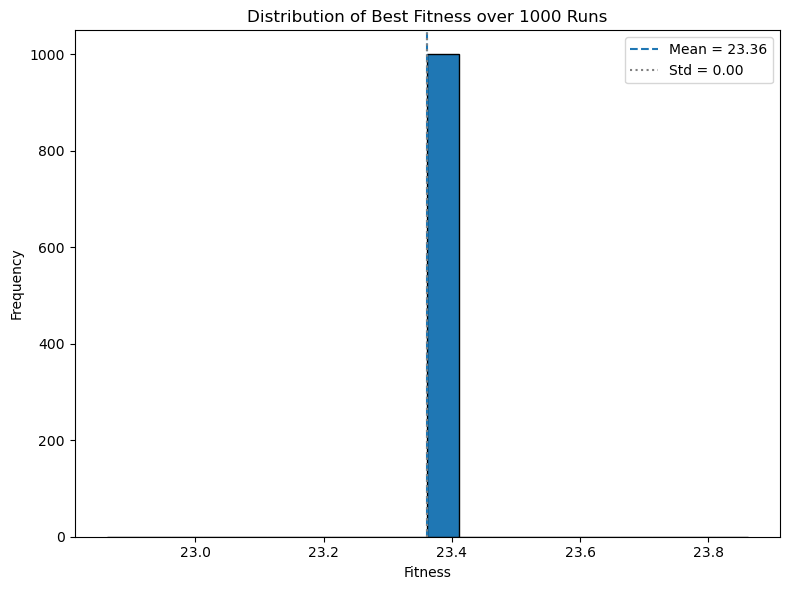

Mean fitness: 23.3618
Std deviation of fitness: 0.0000


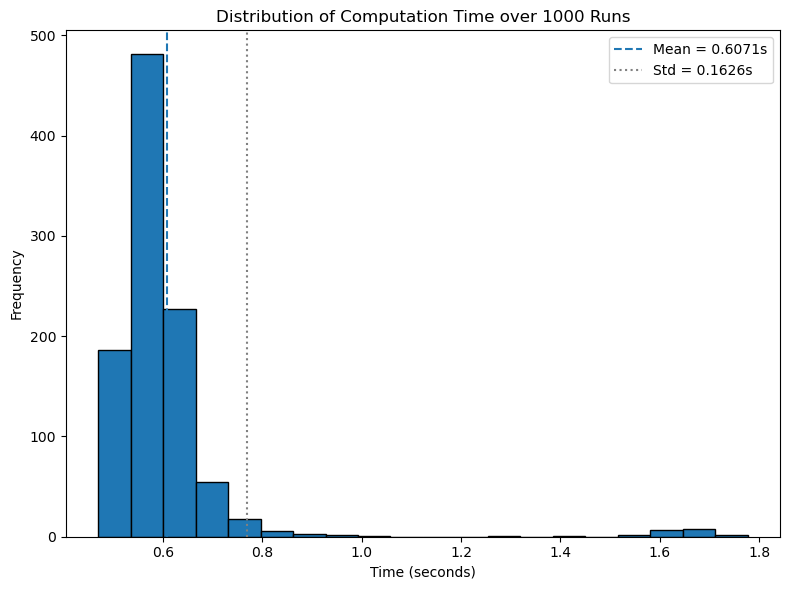

Mean computation time: 0.6071 seconds
Std deviation of time: 0.1626 seconds


(23.361765, 1.9073486e-06, 0.6071416606903076, 0.16264793448670659)

In [23]:
plot_distributions(model=model, runs=1000)